In [13]:
import logging

import numpy as np
import matplotlib.pyplot as plt

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(levelname)s %(name)-40s :: %(message)s'
)


# Inverse Obstacle problem 

Operator that maps the shape of a sound-soft obstacle to the far-field measurements. 
The scattering problem is described by

$$
        \begin{cases}
            \Delta u +\kappa^2 u = 0 & \text{ in } \mathbb{R}^2\backslash\overline{D}\\
             u = 0  & \text{ on } \partial D\\
            \displaystyle{\lim_{r\to\infty}}r^{\frac{1}{2}}(\frac{\partial u^s}{\partial r}-i\kappa u^s)=0 & \text{ for } r=|x|,
        \end{cases}
$$
where $u=u^s+u^i$ is the total field and $D$ is a bounded obstacle in $\mathbb{R}^2$ with $\partial D\in\mathcal{C}^2$.
    

In [28]:
from  regpy.vecsps import UniformGridFcts
from  dirichlet_op import DirichletOp
from  regpy.vecsps.curve import GenTrigDiscr

N_meas=64
N_inc=1
Y_dim=N_meas*N_inc
codomain=UniformGridFcts(np.linspace(0, 2*np.pi, Y_dim, endpoint=False), dtype=complex)

#Forward operator
op = DirichletOp(
    domain=GenTrigDiscr(64),
    codomain=codomain,
    kappa = 1,
    true_curve='apple',
    N_ieq_synth=64,
    N_ieq = 128,  
    N_inc = N_inc,
    N_meas = N_meas,   
    N_FK = 32
)


In [29]:
from regpy.solvers import RegularizationSetting
from regpy.hilbert import L2, Sobolev

setting = RegularizationSetting(op=op, penalty=Sobolev, data_fid=L2)

#Exact data
exact_solution=op.bd_ex_curve
farfield = op._create_synthetic_data()

#Gaussian data
noise_level = 0.01
noise = op.codomain.randn()
noise = noise_level*setting.h_codomain.norm(farfield)/setting.h_codomain.norm(noise)*noise
data = farfield+noise

#Initial guess
t = 2*np.pi*np.arange(0, op.N_FK)/op.N_FK
init = 0.45*np.append(np.cos(t), np.sin(t)).reshape((2, op.N_FK))
init=init.flatten()

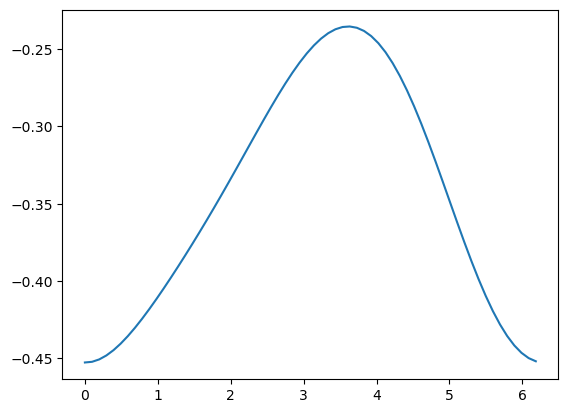

In [32]:
x= op.codomain.coords[0]
y = farfield
plt.plot(x,np.real(y))


2024-04-21 12:27:27,036 INFO CountIterations                          :: iteration = 0 / 100
2024-04-21 12:27:27,037 INFO Discrepancy                              :: relative discrepancy = 9.54, tolerance = 2.10
2024-04-21 12:27:27,075 INFO NewtonCG                                 :: Inner CG iteration required 1 steps.
2024-04-21 12:27:27,155 INFO CountIterations                          :: iteration = 1 / 100
2024-04-21 12:27:27,157 INFO Discrepancy                              :: relative discrepancy = 6.25, tolerance = 2.10
2024-04-21 12:27:27,185 INFO NewtonCG                                 :: Inner CG iteration required 1 steps.
2024-04-21 12:27:27,286 INFO CountIterations                          :: iteration = 2 / 100
2024-04-21 12:27:27,287 INFO Discrepancy                              :: relative discrepancy = 4.61, tolerance = 2.10
2024-04-21 12:27:27,327 INFO NewtonCG                                 :: Inner CG iteration required 2 steps.
2024-04-21 12:27:27,396 INFO Count

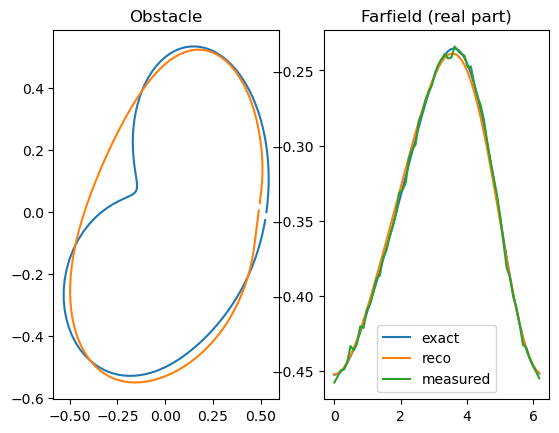

In [36]:
from regpy.solvers.nonlinear.irgnm import IrgnmCG
from regpy.solvers.nonlinear.newton import NewtonCG
import regpy.stoprules as rules

#Solver: NewtonCG or IrgnmCG
solver = NewtonCG(
    setting, farfield, init = init,
        cgmaxit=50, rho=0.8
)

"""
solver = IrgnmCG(
    setting, data,
    regpar=1.,
    regpar_step=0.5,
    init=init
)
"""
stoprule = (
    rules.CountIterations(100) +
    rules.Discrepancy(
        setting.h_codomain.norm, data,
        noiselevel=noise_level,
        tau=2.1
    )
)

#Plot function
fig, axs = plt.subplots(1, 2)
axs[0].set_title('Obstacle')
axs[1].set_title('Farfield (real part)')

reco, reco_data = solver.run(stoprule)
axs[0].plot(*exact_solution.z)
axs[0].plot(*op.domain.bd_eval(reco, nvals=op.N_ieq, nderivs=3).z)

axs[1].plot(op.codomain.coords[0], farfield.real, label='exact')
axs[1].plot(op.codomain.coords[0], reco_data.real, label='reco')
axs[1].plot(op.codomain.coords[0], data.real, label='measured')
axs[1].legend()
#axs[1].set_ylim(ymin=0)
plt.show()